## Analiza F1: Vpliv vremena

In [2]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

fastf1.plotting.setup_mpl(color_scheme='fastf1')

all_laps = []

# Pridobi urnik vseh dirk sezone 2025
schedule = fastf1.get_event_schedule(2025, include_testing=False)

for _, event in schedule.iterrows():
    try:
        # Naloži dirko
        session = fastf1.get_session(2025, event['RoundNumber'], 'R')
        session.load(telemetry=False, weather=True, messages=False)
        
        laps = session.laps.copy()
        weather = session.weather_data.copy()
        
        laps = pd.merge_asof(
            laps.sort_values('LapStartTime'),
            weather.sort_values('Time').rename(columns={'Time': 'LapStartTime'}),
            on='LapStartTime'
        )
        
        # Pretvori čas kroga v sekunde
        laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
        laps['Round'] = event['RoundNumber']
        laps['EventName'] = event['EventName']
        all_laps.append(laps)
        print(f"Loaded {event['EventName']}")
        
    except Exception as e:
        print(f"Skipping round {event['RoundNumber']}: {e}")

# Združi vse dirke v en DataFrame
df = pd.concat(all_laps, ignore_index=True)
print(f"\nTotal laps loaded: {len(df)}")
print(df[['Driver', 'Team', 'LapTimeSeconds', 'TrackTemp', 'Rainfall']].head())

core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.


Loaded Australian Grand Prix
Loaded Chinese Grand Prix
Loaded Japanese Grand Prix
Loaded Bahrain Grand Prix
Loaded Saudi Arabian Grand Prix


core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 81 completed the race distance 00:00.036000 before the recorded end of the session.


Loaded Miami Grand Prix
Loaded Emilia Romagna Grand Prix
Loaded Monaco Grand Prix
Loaded Spanish Grand Prix
Loaded Canadian Grand Prix
Loaded Austrian Grand Prix


core        WARNING 	Fixed incorrect tyre stint information for driver '81'
core        WARNING 	Fixed incorrect tyre stint information for driver '4'
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARNING 	Fixed incorrect tyre stint information for driver '1'


...

Loaded Belgian Grand Prix
Loaded Hungarian Grand Prix
Loaded Dutch Grand Prix
Loaded Italian Grand Prix


core        WARNING 	Driver 1 completed the race distance 00:00.015000 before the recorded end of the session.


Loaded Azerbaijan Grand Prix
Loaded Singapore Grand Prix
Loaded United States Grand Prix
Loaded Mexico City Grand Prix


core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core        WARNING 	Fixed incorrect tyre stint information for driver '63'


Loaded São Paulo Grand Prix
Loaded Las Vegas Grand Prix
Loaded Qatar Grand Prix
Loaded Abu Dhabi Grand Prix

Total laps loaded: 26692
  Driver             Team  LapTimeSeconds  TrackTemp  Rainfall
0    VER  Red Bull Racing         119.392       19.0     False
1    BEA     Haas F1 Team         149.413       19.0     False
2    PIA          McLaren         120.807       19.0     False
3    DOO           Alpine             NaN       19.0     False
4    ALO     Aston Martin         137.178       19.0     False


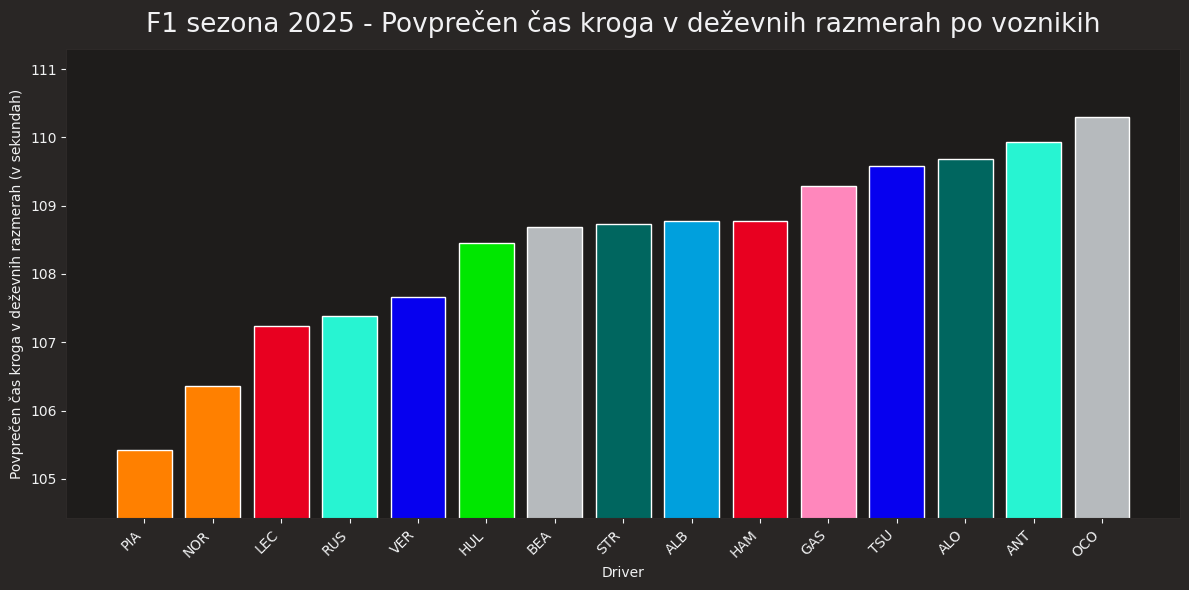

In [3]:
# Ločimo mokre (intermediate) in suhe kroge
wet_laps = df[df['Compound'] == 'INTERMEDIATE']
dry_laps = df[~df['Compound'].isin(['INTERMEDIATE', 'WET'])]

# Upoštevamo samo voznike z vsaj N mokrimi krogi
N = 50
wet_lap_counts = wet_laps.groupby('Driver')['LapTimeSeconds'].count()
valid_drivers = wet_lap_counts[wet_lap_counts >= N].index

# Izračunamo povprečen mokri čas kroga za veljavne voznike
wet_avg = wet_laps[wet_laps['Driver'].isin(valid_drivers)].groupby('Driver')['LapTimeSeconds'].mean().reset_index()
wet_avg.columns = ['Driver', 'AvgWetLapTime']
wet_avg = wet_avg.sort_values('AvgWetLapTime')

fig, ax = plt.subplots(figsize=(12, 6))

# Barve voznikov glede na ekipo
colors_driver = []
for driver in wet_avg['Driver']:
    try:
        style = fastf1.plotting.get_driver_style(driver, ['color'], session)
        colors_driver.append(style['color'])
    except:
        colors_driver.append('#808080')

ax.bar(wet_avg['Driver'], wet_avg['AvgWetLapTime'], color=colors_driver, edgecolor='white')
ax.set_xlabel('Driver')
ax.set_ylabel('Povprečen čas kroga v deževnih razmerah (v sekundah)')
ax.set_title('F1 sezona 2025 - Povprečen čas kroga v deževnih razmerah po voznikih')
ax.set_ylim(wet_avg['AvgWetLapTime'].min() - 1, wet_avg['AvgWetLapTime'].max() + 1)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
# Preverimo katere dirke so bile deževne
print(f"Mokri krogi: {len(wet_laps)}")
print(f"Suhi krogi: {len(dry_laps)}")
print(wet_laps[['EventName', 'Round']].drop_duplicates())

Mokri krogi: 1597
Suhi krogi: 25095
                   EventName  Round
0      Australian Grand Prix      1
12393     British Grand Prix     12
13219     Belgian Grand Prix     13


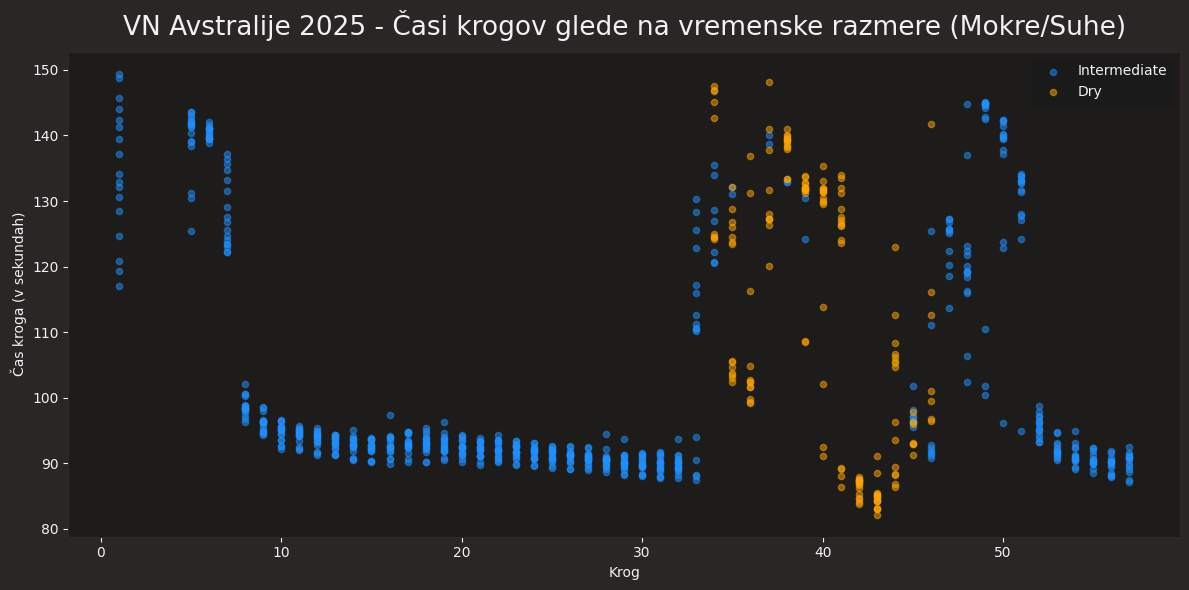

In [5]:
# Nato analiziramo kroge za vsako izmed teh dirk

australia = df[df['EventName'] == 'Australian Grand Prix']

australia_wet = australia[australia['Compound'] == 'INTERMEDIATE']
australia_dry = australia[australia['Compound'].isin(['MEDIUM', 'HARD'])]

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(australia_wet['LapNumber'], australia_wet['LapTimeSeconds'],
           alpha=0.5, s=20, color='dodgerblue', label='Intermediate')
ax.scatter(australia_dry['LapNumber'], australia_dry['LapTimeSeconds'],
           alpha=0.5, s=20, color='orange', label='Dry')

ax.set_xlabel('Krog')
ax.set_ylabel('Čas kroga (v sekundah)')
ax.set_title('VN Avstralije 2025 - Časi krogov glede na vremenske razmere (Mokre/Suhe)')
ax.legend()
plt.tight_layout()
plt.show()

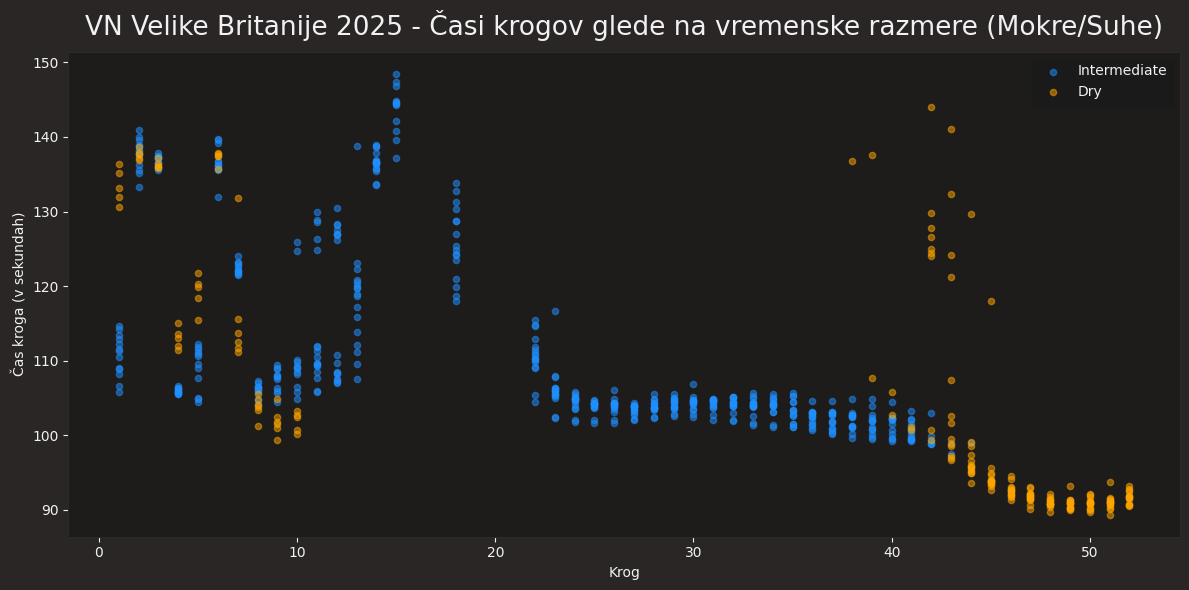

In [6]:
britain = df[df['EventName'] == 'British Grand Prix']

britain_wet = britain[britain['Compound'] == 'INTERMEDIATE']
britain_dry = britain[britain['Compound'].isin(['MEDIUM', 'HARD', 'SOFT'])]

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(britain_wet['LapNumber'], britain_wet['LapTimeSeconds'],
           alpha=0.5, s=20, color='dodgerblue', label='Intermediate')
ax.scatter(britain_dry['LapNumber'], britain_dry['LapTimeSeconds'],
           alpha=0.5, s=20, color='orange', label='Dry')

ax.set_xlabel('Krog')
ax.set_ylabel('Čas kroga (v sekundah)')
ax.set_title('VN Velike Britanije 2025 - Časi krogov glede na vremenske razmere (Mokre/Suhe)')
ax.legend()
plt.tight_layout()
plt.show()

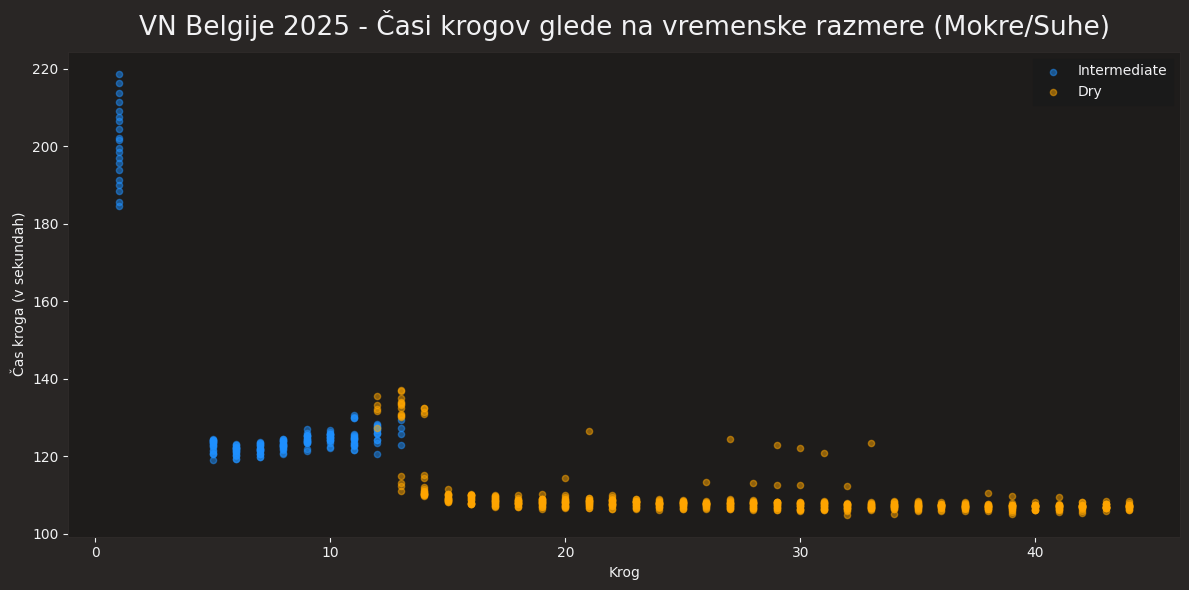

In [7]:
belgium = df[df['EventName'] == 'Belgian Grand Prix']

belgium_wet = belgium[belgium['Compound'] == 'INTERMEDIATE']
belgium_dry = belgium[belgium['Compound'].isin(['MEDIUM', 'HARD', 'SOFT', 'None'])]

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(belgium_wet['LapNumber'], belgium_wet['LapTimeSeconds'],
           alpha=0.5, s=20, color='dodgerblue', label='Intermediate')
ax.scatter(belgium_dry['LapNumber'], belgium_dry['LapTimeSeconds'],
           alpha=0.5, s=20, color='orange', label='Dry')

ax.set_xlabel('Krog')
ax.set_ylabel('Čas kroga (v sekundah)')
ax.set_title('VN Belgije 2025 - Časi krogov glede na vremenske razmere (Mokre/Suhe)')
ax.legend()
plt.tight_layout()
plt.show()